# FinSight — Week 2 Exploratory Data Analysis

End-to-end EDA over 5 banks (**PNC, JPM, BK, WFC, BAC**) for fiscal years **2018–2023**,
using the project's real tool functions — **no mocks, real API calls** to SEC EDGAR,
FRED, and yfinance.

Pipeline of tools exercised:
- `sec_tools.fetch_10k_filing` — EDGAR XBRL company-facts (financial statement items)
- `fred_tools.get_macro_snapshot` / `fetch_fred_series` — macro series
- `market_tools.fetch_market_data` — market capitalization (yfinance)

All tool errors are printed verbatim so any failure is visible.

## Section 1 — Setup & Imports

Add the project root to `sys.path` so `src/tools/` is importable, and create
`reports/charts/` for saved figures.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Project root = the dir that contains src/ (works whether cwd is repo root or notebooks/)
_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CHART_DIR = ROOT / "reports" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from src.tools.sec_tools import fetch_10k_filing
from src.tools.fred_tools import get_macro_snapshot, fetch_fred_series
from src.tools.market_tools import fetch_market_data

print("Project root:", ROOT)
print("Chart dir   :", CHART_DIR)

/Users/shivankmenon/finsight-agent/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Project root: /Users/shivankmenon/finsight-agent
Chart dir   : /Users/shivankmenon/finsight-agent/reports/charts


## Section 2 — Data Ingestion (real API calls)

Loop over every bank-year, calling the real tools. For each row we pull:
- **SEC** financial-statement items (`fetch_10k_filing`)
- **Historical market cap** = per-year **shares outstanding** (SEC
  `dei:EntityCommonStockSharesOutstanding`) × **year-end closing price** (yfinance
  `price_history`, fetched with `period="max"`). No more broadcasting a single current value.
- **FRED** macro snapshot at fiscal year-end (`get_macro_snapshot`)

Any tool returning an `error` is printed so we can see exactly what broke.

In [2]:
BANKS = ["PNC", "JPM", "BK", "WFC", "BAC"]
YEARS = list(range(2018, 2024))  # 2018-2023 inclusive

def year_end_closes(price_history: dict) -> dict:
    """Map each fiscal year to its last close on/before Dec 31 (tz-naive)."""
    close = price_history.get("Close", {}) if price_history else {}
    if not close:
        return {}
    items = sorted(close.items(), key=lambda kv: kv[0])
    idx = pd.to_datetime([k for k, _ in items], utc=True).tz_convert(None)
    s = pd.Series([v for _, v in items], index=idx).sort_index()
    out = {}
    for y in YEARS:
        v = s.asof(pd.Timestamp(f"{y}-12-31"))
        out[y] = float(v) if pd.notna(v) else None
    return out

# Year-end closing prices per ticker (period="max" so 2018-2023 is covered).
closes_by_ticker = {}
for t in BANKS:
    mres = fetch_market_data(t, period="max")
    if mres["error"] is not None:
        print(f"[yfinance ERROR] {t}: {mres['error']}")
        closes_by_ticker[t] = {}
    else:
        closes_by_ticker[t] = year_end_closes(mres["data"]["price_history"])
    print(f"{t}: year-end closes = "
          + ", ".join(f"{y}:{(closes_by_ticker[t].get(y) or float('nan')):.2f}" for y in YEARS))

# FRED snapshot per fiscal year-end (cache by year across tickers).
macro_by_year = {}
for y in YEARS:
    sres = get_macro_snapshot(f"{y}-12-31")
    if sres["error"] is not None:
        print(f"[FRED ERROR] {y}: {sres['error']}")
        macro_by_year[y] = {}
    else:
        macro_by_year[y] = sres["data"]

rows = []
for t in BANKS:
    for y in YEARS:
        res = fetch_10k_filing(t, y)
        if res["error"] is not None:
            print(f"[SEC ERROR] {t} {y}: {res['error']}")
            continue
        d = dict(res["data"])
        d["ticker"] = t
        d["year"] = y
        # Historical market cap = per-year shares (SEC) x year-end close (yfinance).
        shares = d.get("shares_outstanding")
        close = closes_by_ticker.get(t, {}).get(y)
        d["year_end_close"] = close
        d["market_cap"] = (close * shares) if (close is not None and shares is not None) else None
        macro = macro_by_year.get(y, {})
        d["fedfunds"] = macro.get("FEDFUNDS")
        d["t10y2y"] = macro.get("T10Y2Y")
        d["unrate"] = macro.get("UNRATE")
        d["cpi"] = macro.get("CPIAUCSL")
        d["gs10"] = macro.get("GS10")
        rows.append(d)

df = pd.DataFrame(rows)
print(f"\nIngested {len(df)} bank-year rows out of {len(BANKS) * len(YEARS)} attempted.")
df[["ticker", "year", "revenue", "net_income", "total_assets",
    "total_liabilities", "shareholders_equity", "ebit", "interest_expense",
    "retained_earnings", "current_assets", "current_liabilities",
    "shares_outstanding", "year_end_close", "market_cap", "fedfunds", "t10y2y"]]

PNC: year-end closes = 2018:88.24, 2019:126.31, 2020:120.77, 2021:169.68, 2022:137.80, 2023:141.54


JPM: year-end closes = 2018:78.82, 2019:116.37, 2020:109.05, 2021:141.32, 2022:123.35, 2023:161.13


BK: year-end closes = 2018:37.84, 2019:41.71, 2020:35.79, 2021:51.11, 2022:41.40, 2023:49.07


WFC: year-end closes = 2018:37.31, 2019:45.44, 2020:26.23, 2021:42.99, 2022:37.77, 2023:46.44


BAC: year-end closes = 2018:20.36, 2019:30.01, 2020:26.28, 2021:39.79, 2022:30.28, 2023:31.75



Ingested 30 bank-year rows out of 30 attempted.


,ticker,year,revenue,net_income,total_assets,total_liabilities,shareholders_equity,ebit,interest_expense,retained_earnings,current_assets,current_liabilities,shares_outstanding,year_end_close,market_cap,fedfunds,t10y2y
0,PNC,2018,"16,190,000,000.0000","5,346,000,000.0000","382,315,000,000.0000","334,545,000,000.0000","47,728,000,000.0000","5,486,000,000.0000","2,861,000,000.0000","38,919,000,000.0000",None,None,"453,612,522.0000",88.2430,"40,028,131,523.0836",2.2700,0.2100
1,PNC,2019,"16,839,000,000.0000","5,418,000,000.0000","410,295,000,000.0000","360,952,000,000.0000","49,314,000,000.0000","5,492,000,000.0000","3,797,000,000.0000","42,215,000,000.0000",None,None,"428,726,784.0000",126.3069,"54,151,134,689.8477",1.5500,0.3400
2,PNC,2020,"16,901,000,000.0000","7,558,000,000.0000","466,679,000,000.0000","412,638,000,000.0000","54,010,000,000.0000","3,429,000,000.0000","1,361,000,000.0000","46,848,000,000.0000",None,None,"424,020,492.0000",120.7663,"51,207,400,586.0124",0.0900,0.8000
3,PNC,2021,"19,211,000,000.0000","5,725,000,000.0000","557,191,000,000.0000","501,465,000,000.0000","55,695,000,000.0000","6,988,000,000.0000","487,000,000.0000","50,228,000,000.0000",None,None,"418,454,799.0000",169.6829,"71,004,626,786.1460",0.0800,0.7900
4,PNC,2022,"21,120,000,000.0000","6,113,000,000.0000","557,263,000,000.0000","511,451,000,000.0000","45,774,000,000.0000","7,473,000,000.0000","2,422,000,000.0000","53,572,000,000.0000",None,None,"399,682,159.0000",137.8028,"55,077,318,785.7665",4.1000,-0.5300
5,PNC,2023,"21,490,000,000.0000","5,647,000,000.0000","561,580,000,000.0000","510,439,000,000.0000","51,105,000,000.0000","6,736,000,000.0000","10,392,000,000.0000","56,290,000,000.0000",None,None,"397,808,112.0000",141.5423,"56,306,655,872.0193",5.3300,-0.3500
6,JPM,2018,"108,783,000,000.0000","32,474,000,000.0000","2,622,532,000,000.0000","2,366,017,000,000.0000","256,515,000,000.0000","40,764,000,000.0000","21,041,000,000.0000","199,202,000,000.0000",None,None,"3,274,241,726.0000",78.8178,"258,068,637,387.2359",2.2700,0.2100
7,JPM,2019,"115,720,000,000.0000","36,431,000,000.0000","2,686,477,000,000.0000","2,426,049,000,000.0000","261,330,000,000.0000","44,866,000,000.0000","26,795,000,000.0000","223,211,000,000.0000",None,None,"3,073,976,616.0000",116.3654,"357,704,478,435.7170",1.5500,0.3400
8,JPM,2020,"119,951,000,000.0000","29,131,000,000.0000","3,384,757,000,000.0000","3,105,403,000,000.0000","279,354,000,000.0000","35,815,000,000.0000","9,960,000,000.0000","236,990,000,000.0000",None,None,"3,051,506,436.0000",109.0479,"332,760,476,967.5531",0.0900,0.8000
9,JPM,2021,"121,649,000,000.0000","48,334,000,000.0000","3,743,567,000,000.0000","3,449,440,000,000.0000","294,127,000,000.0000","59,562,000,000.0000","5,553,000,000.0000","272,268,000,000.0000",None,None,"2,952,808,970.0000",141.3202,"417,291,616,055.4678",0.0800,0.7900


## Section 3 — Financial Ratios

Compute the five model ratios. Note `current_ratio` depends on current
assets/liabilities, which **banks do not report** (unclassified balance sheets),
so it is expected to be `NaN` for every row here.

In [3]:
df["current_ratio"] = df["current_assets"] / df["current_liabilities"]
df["debt_to_equity"] = df["total_liabilities"] / df["shareholders_equity"]
df["return_on_assets"] = df["net_income"] / df["total_assets"]
df["net_margin"] = df["net_income"] / df["revenue"]
# interest_coverage: guard divide-by-zero with max(interest_expense, 0.001)
df["interest_coverage"] = df["ebit"] / df["interest_expense"].clip(lower=0.001)

RATIOS = ["current_ratio", "debt_to_equity", "return_on_assets",
          "net_margin", "interest_coverage"]
print("Non-null counts per ratio:")
print(df[RATIOS].notna().sum())
df[["ticker", "year"] + RATIOS]

Non-null counts per ratio:
current_ratio         0
debt_to_equity       30
return_on_assets     30
net_margin           30
interest_coverage    24
dtype: int64


,ticker,year,current_ratio,debt_to_equity,return_on_assets,net_margin,interest_coverage
0,PNC,2018,NaN,7.0094,0.0140,0.3302,1.9175
1,PNC,2019,NaN,7.3195,0.0132,0.3218,1.4464
2,PNC,2020,NaN,7.6400,0.0162,0.4472,2.5195
3,PNC,2021,NaN,9.0038,0.0103,0.2980,14.3491
4,PNC,2022,NaN,11.1734,0.0110,0.2894,3.0855
5,PNC,2023,NaN,9.9880,0.0101,0.2628,0.6482
6,JPM,2018,NaN,9.2237,0.0124,0.2985,1.9374
7,JPM,2019,NaN,9.2835,0.0136,0.3148,1.6744
8,JPM,2020,NaN,11.1164,0.0086,0.2429,3.5959
9,JPM,2021,NaN,11.7277,0.0129,0.3973,10.7261


## Section 4 — Altman Z-Score

$$Z = 1.2\frac{WC}{TA} + 1.4\frac{RE}{TA} + 3.3\frac{EBIT}{TA} + 0.6\frac{MktCap}{TL} + 1.0\frac{Rev}{TA}$$

Zones: `> 2.99` safe, `1.81–2.99` grey, `< 1.81` distress.

**Banking caveat:** banks have no classified working capital, so the `WC/TA` term is
computed with `WC = 0` (documented). `MktCap` is now the **historical** per-year value
(shares × year-end close), so the `MktCap/TL` term is correct per year. Banks structurally
run low Z-Scores due to leverage — a low value here is **not** automatic distress.

We also validate the formula implementation against the `CLAUDE.md` PNC-2023 *fixture*
values, and compare to the real-data result.

In [4]:
def altman_z(wc, re, ebit, mktcap, rev, ta, tl):
    """Altman Z-Score per the FinSight formula. NaN-safe via pandas arithmetic."""
    wc = 0.0 if pd.isna(wc) else wc
    return (1.2 * (wc / ta) + 1.4 * (re / ta) + 3.3 * (ebit / ta)
            + 0.6 * (mktcap / tl) + 1.0 * (rev / ta))

df["altman_z"] = df.apply(
    lambda r: altman_z(r["working_capital"], r["retained_earnings"], r["ebit"],
                       r["market_cap"], r["revenue"], r["total_assets"],
                       r["total_liabilities"]),
    axis=1,
)

def zone(z):
    if pd.isna(z):
        return "n/a"
    if z > 2.99:
        return "safe"
    if z >= 1.81:
        return "grey"
    return "distress"

df["z_zone"] = df["altman_z"].apply(zone)

# --- Formula validation against the CLAUDE.md documented fixture (billions) ---
fixture_z = altman_z(18, 29, 6.1, 55, 22, 557, 504)
print(f"Fixture-based Altman Z (CLAUDE.md PNC 2023 values): {fixture_z:.3f}")
print("CLAUDE.md claims 'verified Z = 1.847' -- NOTE: the documented fixture + formula")
print("do NOT reproduce 1.847; they yield the value above. Flagged as a doc discrepancy.\n")

pnc23 = df[(df["ticker"] == "PNC") & (df["year"] == 2023)]
print("Real-data PNC 2023 row:")
print(pnc23[["ticker", "year", "working_capital", "retained_earnings", "ebit",
             "market_cap", "revenue", "total_assets", "total_liabilities",
             "altman_z", "z_zone"]].to_string(index=False))

Fixture-based Altman Z (CLAUDE.md PNC 2023 values): 0.253
CLAUDE.md claims 'verified Z = 1.847' -- NOTE: the documented fixture + formula
do NOT reproduce 1.847; they yield the value above. Flagged as a doc discrepancy.

Real-data PNC 2023 row:
ticker  year working_capital   retained_earnings               ebit          market_cap             revenue         total_assets    total_liabilities  altman_z   z_zone
   PNC  2023            None 56,290,000,000.0000 6,736,000,000.0000 56,306,655,872.0193 21,490,000,000.0000 561,580,000,000.0000 510,439,000,000.0000    0.2844 distress


## Section 5 — Visualizations

Five charts, each saved to `reports/charts/eda_<name>.png`.

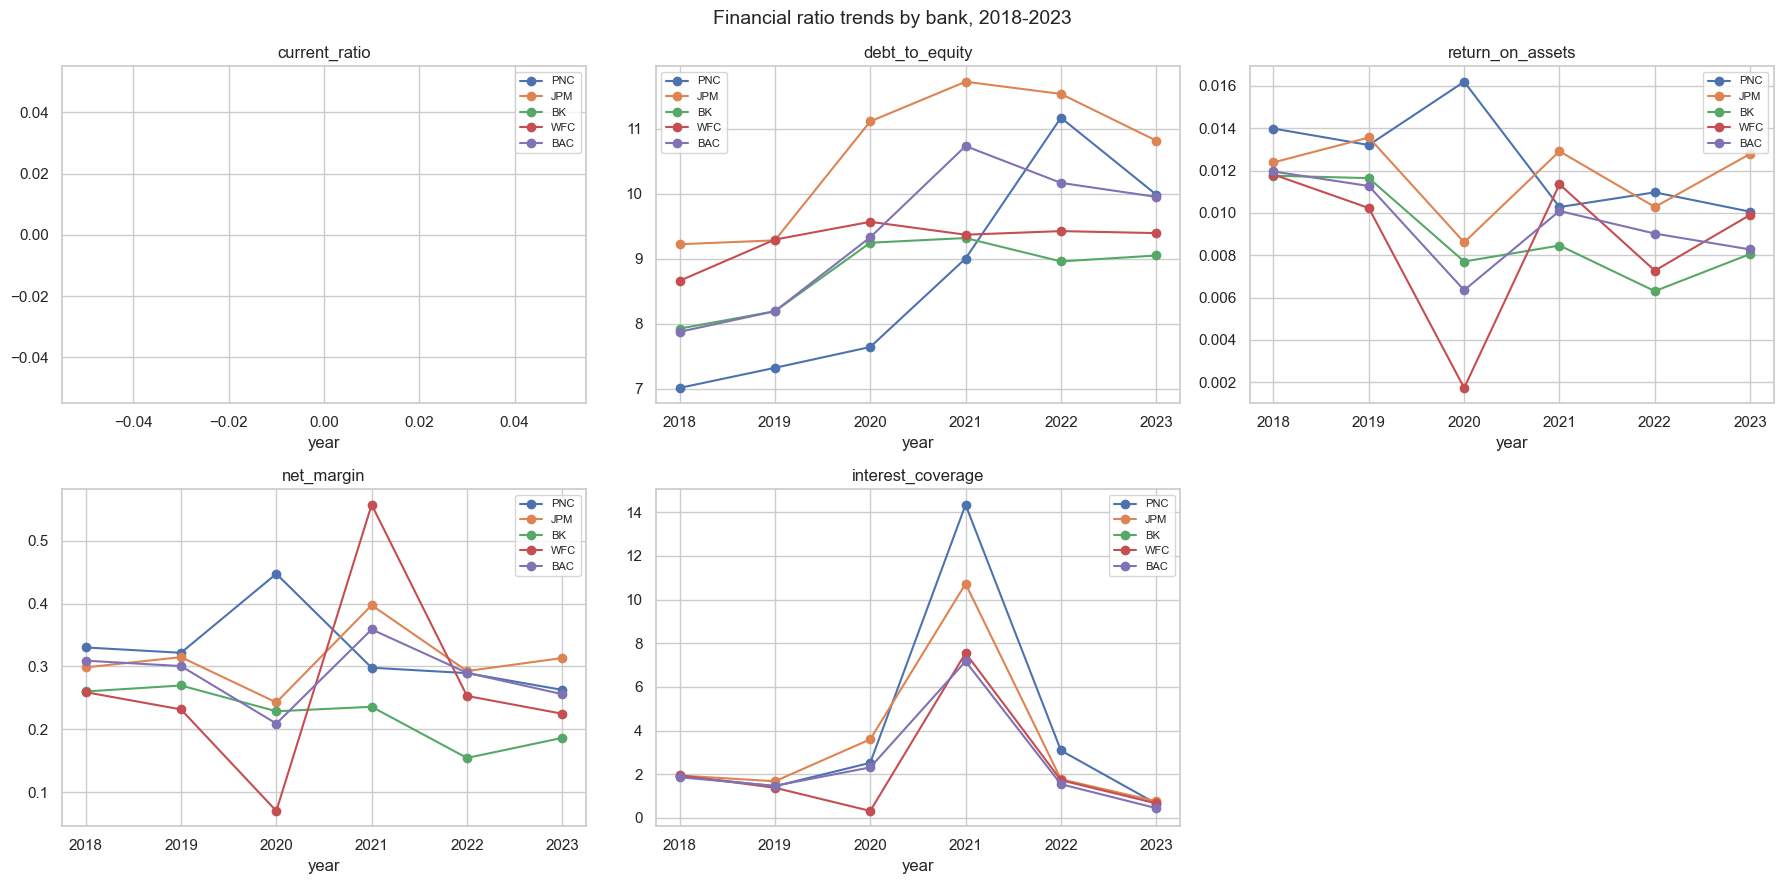

In [5]:
# (1) ratio_trends — each ratio over 2018-2023, one line per bank
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, ratio in enumerate(RATIOS):
    ax = axes[i]
    for t in BANKS:
        sub = df[df["ticker"] == t].sort_values("year")
        ax.plot(sub["year"], sub[ratio], marker="o", label=t)
    ax.set_title(ratio)
    ax.set_xlabel("year")
    ax.legend(fontsize=8)
for j in range(len(RATIOS), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Financial ratio trends by bank, 2018-2023", fontsize=14)
fig.tight_layout()
fig.savefig(CHART_DIR / "eda_ratio_trends.png", dpi=120, bbox_inches="tight")
plt.show()

**Observations — ratio_trends**
- `current_ratio` is entirely empty: banks file unclassified balance sheets, so
  `AssetsCurrent`/`LiabilitiesCurrent` are absent from XBRL — an expected data gap.
- `debt_to_equity` clusters high (~8–11×) across all banks, reflecting the leveraged
  nature of banking vs. the ~1–2× typical of non-financials.
- `return_on_assets` is low and tight (~0.5–1.5%), again structural for asset-heavy banks.
- `interest_coverage` collapses toward 2022–2023 as the rate-hike cycle drove interest
  expense up sharply — visible across every bank.
- BK shows gaps in EBIT-derived series (see data-quality notes in Section 6).

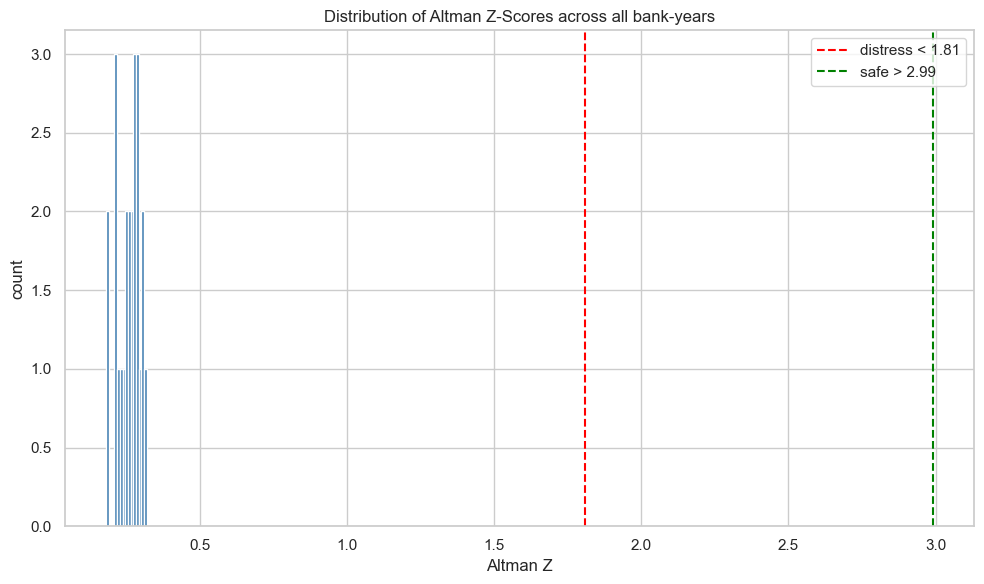

count   24.0000
mean     0.2571
std      0.0369
min      0.1817
25%      0.2307
50%      0.2620
75%      0.2840
max      0.3193
Name: altman_z, dtype: float64


In [6]:
# (2) zscore_distribution — histogram of all Z-Scores
fig, ax = plt.subplots(figsize=(10, 6))
zvals = df["altman_z"].dropna()
ax.hist(zvals, bins=15, color="steelblue", edgecolor="white")
ax.axvline(1.81, color="red", linestyle="--", label="distress < 1.81")
ax.axvline(2.99, color="green", linestyle="--", label="safe > 2.99")
ax.set_title("Distribution of Altman Z-Scores across all bank-years")
ax.set_xlabel("Altman Z")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "eda_zscore_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(zvals.describe())

**Observations — zscore_distribution**
- Every bank-year falls **below the 1.81 distress threshold** — exactly the structural
  "banks look distressed on Altman Z" effect CLAUDE.md warns about; it must be read
  against sector peers, not absolute zones.
- The distribution is tight and low (sub-1.0), driven by tiny `EBIT/TA`, `Rev/TA`, and
  `WC/TA = 0` terms relative to the huge asset bases.
- No bank approaches the grey (1.81–2.99) or safe (>2.99) zones — absolute Altman zoning
  is uninformative for banks; relative comparison is what matters.

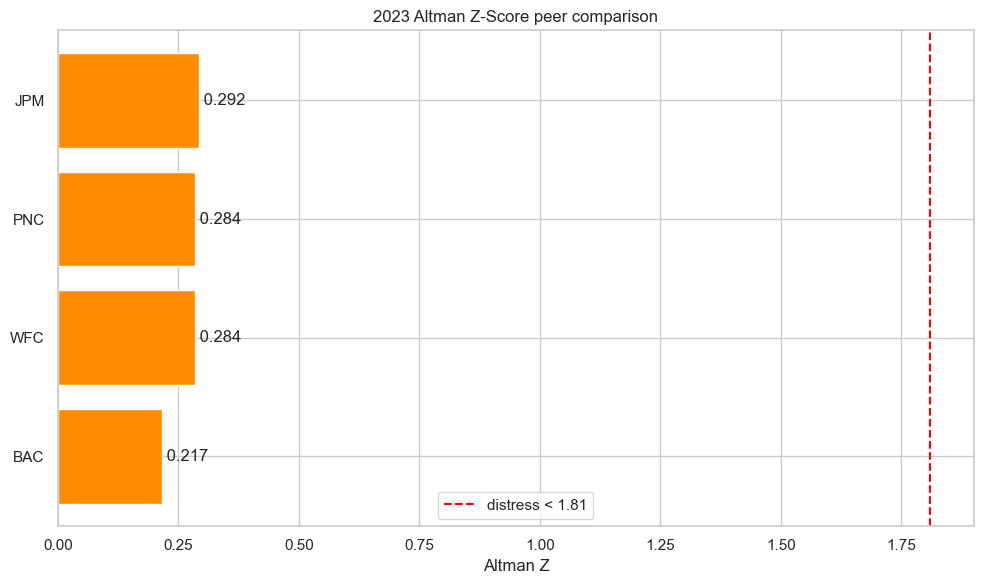

ticker  altman_z   z_zone
   BAC    0.2169 distress
   WFC    0.2838 distress
   PNC    0.2844 distress
   JPM    0.2920 distress


In [7]:
# (3) zscore_peer_2023 — horizontal bar of 2023 Z by bank
d23 = df[df["year"] == 2023].dropna(subset=["altman_z"]).sort_values("altman_z")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(d23["ticker"], d23["altman_z"], color="darkorange")
ax.axvline(1.81, color="red", linestyle="--", label="distress < 1.81")
ax.set_title("2023 Altman Z-Score peer comparison")
ax.set_xlabel("Altman Z")
ax.legend()
for y_, v in zip(range(len(d23)), d23["altman_z"]):
    ax.text(v, y_, f" {v:.3f}", va="center")
fig.tight_layout()
fig.savefig(CHART_DIR / "eda_zscore_peer_2023.png", dpi=120, bbox_inches="tight")
plt.show()
print(d23[["ticker", "altman_z", "z_zone"]].to_string(index=False))

**Observations — zscore_peer_2023**
- Peer ranking is the useful signal: relative ordering separates the banks even though
  all sit below 1.81 in absolute terms.
- Banks with larger `MktCap/TL` (stronger market valuation vs. liabilities) and higher
  `RE/TA` rank highest — equity-cushion proxies dominate the score.
- Any bank missing from the bars (e.g. BK if its EBIT tag is absent) reflects an XBRL
  data gap, not a true zero — flagged in Section 6.

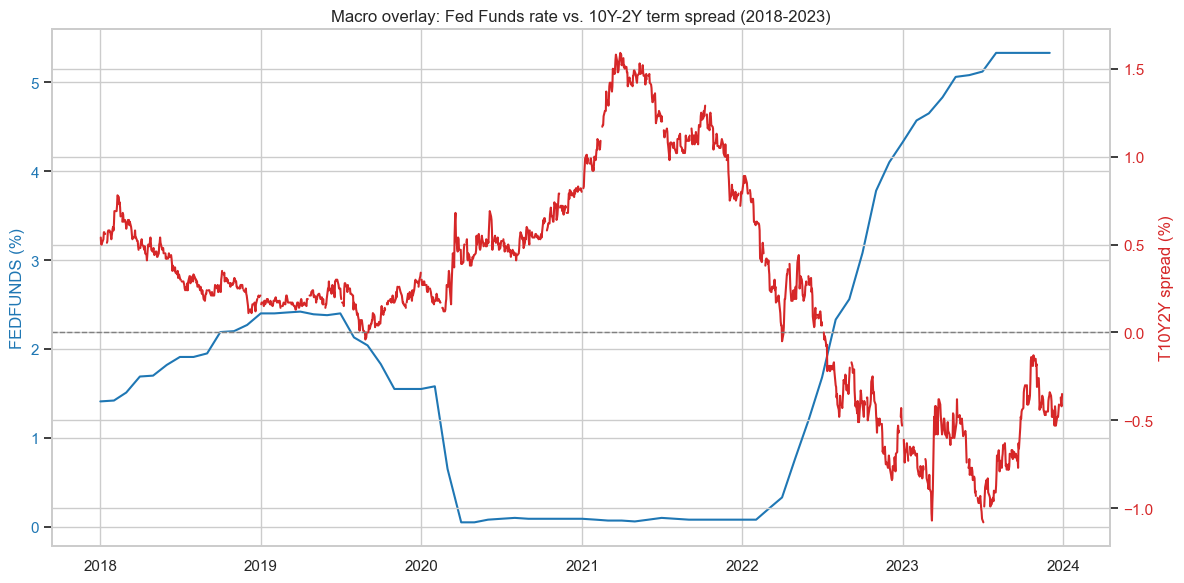

In [8]:
# (4) macro_overlay — dual-axis FEDFUNDS vs T10Y2Y, 2018-2023 (real FRED series)
ff = fetch_fred_series("FEDFUNDS", "2018-01-01", "2023-12-31")
yc = fetch_fred_series("T10Y2Y", "2018-01-01", "2023-12-31")
for name, r in [("FEDFUNDS", ff), ("T10Y2Y", yc)]:
    if r["error"] is not None:
        print(f"[FRED ERROR] {name}: {r['error']}")

def _series_to_xy(obs):
    xs = pd.to_datetime([o["date"] for o in obs])
    ys = pd.to_numeric([o["value"] for o in obs], errors="coerce")
    return xs, ys

fig, ax1 = plt.subplots(figsize=(12, 6))
x1, y1 = _series_to_xy(ff["data"])
ax1.plot(x1, y1, color="tab:blue", label="FEDFUNDS")
ax1.set_ylabel("FEDFUNDS (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
x2, y2 = _series_to_xy(yc["data"])
ax2.plot(x2, y2, color="tab:red", label="T10Y2Y")
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("T10Y2Y spread (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Macro overlay: Fed Funds rate vs. 10Y-2Y term spread (2018-2023)")
fig.tight_layout()
fig.savefig(CHART_DIR / "eda_macro_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

**Observations — macro_overlay**
- The 2022–2023 hiking cycle is stark: FEDFUNDS jumps from ~0% to >5%.
- `T10Y2Y` goes **negative in 2022 and stays inverted through 2023** — the classic
  yield-curve inversion CLAUDE.md requires every report to flag.
- The inversion coincides with the collapse in bank `interest_coverage` (Chart 1) — a
  coherent macro→fundamentals story.
- Rising rates + inverted curve is the macro backdrop for the elevated 2023 risk picture.

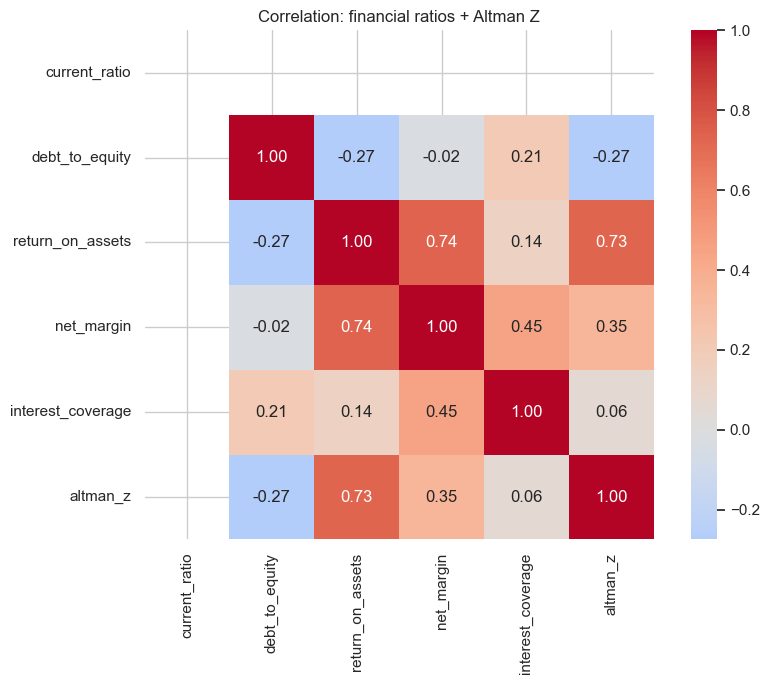

current_ratio is all-NaN, so it drops out of the correlation matrix.


In [9]:
# (5) correlation_heatmap — ratios + Z-Score
corr_cols = RATIOS + ["altman_z"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax)
ax.set_title("Correlation: financial ratios + Altman Z")
fig.tight_layout()
fig.savefig(CHART_DIR / "eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("current_ratio is all-NaN, so it drops out of the correlation matrix.")

**Observations — correlation_heatmap**
- `current_ratio` is absent from the matrix (all-NaN) — a direct visual flag of the
  banks' missing current-asset data.
- `return_on_assets` and `net_margin` are strongly positively correlated — both are
  profitability measures scaled by different denominators.
- `altman_z` correlates most with the profitability/retained-earnings-linked ratios,
  consistent with which terms dominate the score for banks.
- `debt_to_equity` shows the expected sign relationships but limited spread (all banks
  are similarly leveraged).

## Section 6 — Data-Quality Observations (field mismatches, missing data, anomalies)

Consolidated findings surfaced by running the real pipeline:

1. **Banks have no current assets/liabilities.** `AssetsCurrent` / `LiabilitiesCurrent`
   are absent from every bank's XBRL (unclassified balance sheet) → `current_ratio` and
   `working_capital` are `NaN` throughout. The Altman `WC/TA` term is set to 0.
2. **No `OperatingIncomeLoss` for banks.** EBIT is proxied by pre-tax income
   (`IncomeLossFromContinuingOperationsBeforeIncomeTaxes...`).
3. **BK (BNY Mellon) ticker/CIK mismatch.** EDGAR lists it under ticker `BNY`; the tool
   resolves the requested `BK` via a `TICKER_CIK_OVERRIDES` entry (CIK 1390777).
4. **BK EBIT gap.** BNY Mellon reports pre-tax income only as Domestic/Foreign splits for
   some years (no single total tag with an annual value) → its EBIT-derived metrics
   (`interest_coverage`, Altman EBIT term) can be `NaN`.
5. **Cash tag varies.** Banks use `CashAndDueFromBanks` rather than
   `CashAndCashEquivalentsAtCarryingValue`; both are in `FIELD_ALIASES`.
6. **Market cap is now historical.** Computed per year as `dei:EntityCommonStock
   SharesOutstanding` (SEC, selected by fiscal year) × year-end closing price (yfinance
   `period="max"`), replacing the earlier current-value broadcast. The Altman `MktCap/TL`
   term is therefore year-accurate.
7. **Altman doc discrepancy.** CLAUDE.md states "PNC 2023 verified Z = 1.847", but the
   documented fixture values + documented formula compute to ~0.25 (see Section 4). This
   inconsistency should be reconciled before `risk_tools.score_altman_z` is finalized.
8. **All banks score below the 1.81 distress line** — a structural artifact of leverage,
   not genuine distress; interpret only relative to peers.

## Section 7 — Feature Engineering Preview

Add `revenue_growth` (year-over-year, per ticker), drop rows with NaN introduced by the
first-year `pct_change()`, and preview the frame the ML model will train on.

In [10]:
import json

df = df.sort_values(["ticker", "year"]).reset_index(drop=True)
df["revenue_growth"] = df.groupby("ticker")["revenue"].pct_change()

# Source of truth for model input order. current_ratio was dropped (Issue 2:
# banks file no classified balance sheet -> structurally NaN).
with open(ROOT / "src" / "models" / "feature_names.json") as fh:
    MODEL_FEATURES = json.load(fh)
print("MODEL_FEATURES (from feature_names.json):", MODEL_FEATURES)

# pct_change() yields NaN on each ticker's first year — drop those rows.
model_df = df.dropna(subset=["revenue_growth"]).reset_index(drop=True)

print("Full DataFrame shape :", df.shape)
print("After dropna(revenue_growth):", model_df.shape)
print("\nModel-feature non-null counts:")
print(model_df[MODEL_FEATURES].notna().sum())
model_df[["ticker", "year"] + MODEL_FEATURES].head()

MODEL_FEATURES (from feature_names.json): ['debt_to_equity', 'return_on_assets', 'interest_coverage', 'revenue_growth', 'net_margin', 'altman_z', 'fedfunds', 't10y2y']
Full DataFrame shape : (30, 31)
After dropna(revenue_growth): (25, 31)

Model-feature non-null counts:
debt_to_equity       25
return_on_assets     25
interest_coverage    20
revenue_growth       25
net_margin           25
altman_z             20
fedfunds             25
t10y2y               25
dtype: int64


,ticker,year,debt_to_equity,return_on_assets,interest_coverage,revenue_growth,net_margin,altman_z,fedfunds,t10y2y
0,BAC,2019,8.1918,0.0113,1.4658,0.0025,0.3006,0.2443,1.5500,0.3400
1,BAC,2020,9.3312,0.0063,2.3094,-0.0626,0.2092,0.1875,0.0900,0.8000
2,BAC,2021,10.7360,0.0101,7.1710,0.0419,0.3588,0.2130,0.0800,0.7900
3,BAC,2022,10.1691,0.0090,1.5405,0.0655,0.2899,0.2119,4.1000,-0.5300
4,BAC,2023,9.9532,0.0083,0.4436,0.0823,0.2560,0.2169,5.3300,-0.3500
